# Introduction to scikit-learn

Scikit-learn is one of the most popular machine learning libraries for Python. It provides simple and efficient tools for data mining and data analysis, built on NumPy, SciPy, and matplotlib.

This notebook provides a comprehensive introduction to the fundamental concepts, components, and workflow of scikit-learn.

## 1. Import Required Libraries

In [1]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn
import sklearn
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier

# Check scikit-learn version
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.6.1


## 2. Understanding scikit-learn's Core Components

Scikit-learn has a consistent API design that makes it easy to use different machine learning algorithms. The core components are:

1. **Estimators**: Any object that learns from data, like classifiers or regressors
2. **Predictors**: Estimators with a `predict()` method
3. **Transformers**: Estimators with a `transform()` method for data preprocessing
4. **Models**: Estimators that also implement a `score()` method

The consistent API follows a simple pattern:
- `fit()`: Learn from data
- `predict()`: Make predictions
- `transform()`: Transform data
- `fit_transform()`: Fit to data, then transform it

In [2]:
# Example of the common scikit-learn workflow pattern

# 1. Get data
X = np.array([[1, 1], [2, 2], [3, 3], [4, 4]])
y = np.array([0, 0, 1, 1])

# 2. Create a model (estimator)
model = LogisticRegression()

# 3. Train the model on data (fit)
model.fit(X, y)

# 4. Use the model to make predictions (predict)
predictions = model.predict(np.array([[2, 2], [4, 4]]))
print("Predictions:", predictions)

# 5. Evaluate the model (score)
print("Model accuracy:", model.score(X, y))

Predictions: [0 1]
Model accuracy: 1.0


## 3. Loading and Exploring Sample Datasets

Scikit-learn comes with several built-in datasets that are perfect for learning machine learning concepts. Let's load and explore some of these datasets.

In [3]:
# Loading the Iris dataset
iris = datasets.load_iris()

# Exploring the dataset structure
print("Dataset keys:", iris.keys())
print("\nFeature names:", iris.feature_names)
print("\nTarget names:", iris.target_names)
print("\nData shape:", iris.data.shape)
print("\nTarget shape:", iris.target.shape)

# Convert to pandas DataFrame for easier exploration
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['species'] = iris_df['target'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

# Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
print(iris_df.head())

Dataset keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names: ['setosa' 'versicolor' 'virginica']

Data shape: (150, 4)

Target shape: (150,)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


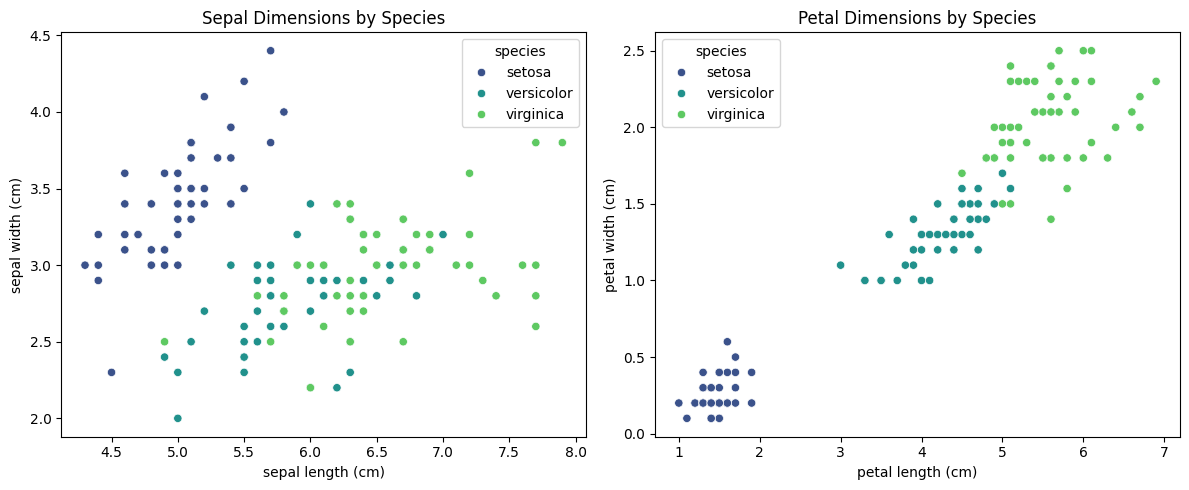

In [4]:
# Visualize the iris dataset
plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot of sepal length vs sepal width
plt.subplot(1, 2, 1)
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', 
                hue='species', data=iris_df, palette='viridis')
plt.title('Sepal Dimensions by Species')

# Plot 2: Scatter plot of petal length vs petal width
plt.subplot(1, 2, 2)
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', 
                hue='species', data=iris_df, palette='viridis')
plt.title('Petal Dimensions by Species')

plt.tight_layout()
plt.show()

Digits dataset shape: (1797, 64)
Target shape: (1797,)


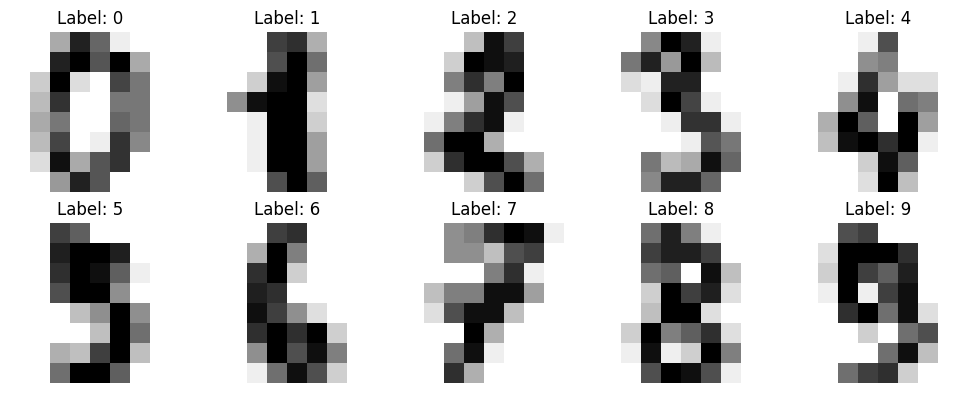

In [5]:
# Loading the digits dataset
digits = datasets.load_digits()

# Display the dataset structure
print("Digits dataset shape:", digits.data.shape)
print("Target shape:", digits.target.shape)

# Visualize a few sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='binary')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
    
plt.tight_layout()
plt.show()

## 4. Preprocessing Data with scikit-learn

Data preprocessing is a critical step in the machine learning workflow. Scikit-learn provides many tools for preprocessing data, including:

- Scaling features
- Encoding categorical variables
- Handling missing values
- Feature selection and extraction

In [6]:
# Create a sample dataset with numeric and missing values
data = np.array([[1.2, 2.4, np.nan],
                 [2.3, np.nan, 0.1],
                 [np.nan, 1.3, 2.2],
                 [3.2, 4.2, 3.1]])

print("Original data with missing values:")
print(data)

# Handling missing values with SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(data)

print("\nData after imputation:")
print(imputed_data)

Original data with missing values:
[[1.2 2.4 nan]
 [2.3 nan 0.1]
 [nan 1.3 2.2]
 [3.2 4.2 3.1]]

Data after imputation:
[[1.2        2.4        1.8       ]
 [2.3        2.63333333 0.1       ]
 [2.23333333 1.3        2.2       ]
 [3.2        4.2        3.1       ]]


In [7]:
# Feature scaling using StandardScaler and MinMaxScaler

# Create a sample dataset
X = np.array([[-2, 3, -1], 
              [1, 0, -4],
              [4, -2, 2],
              [0, 1, -1]])

print("Original data:")
print(X)

# StandardScaler: Standardize features by removing the mean and scaling to unit variance
# z = (x - mean) / std
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData after StandardScaler (mean=0, std=1):")
print(X_scaled)
print(f"Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"Std: {X_scaled.std(axis=0).round(3)}")

# MinMaxScaler: Scale features to a given range, default [0,1]
# x' = (x - min) / (max - min)
min_max_scaler = MinMaxScaler()
X_min_max = min_max_scaler.fit_transform(X)

print("\nData after MinMaxScaler (range [0,1]):")
print(X_min_max)
print(f"Min: {X_min_max.min(axis=0)}")
print(f"Max: {X_min_max.max(axis=0)}")

Original data:
[[-2  3 -1]
 [ 1  0 -4]
 [ 4 -2  2]
 [ 0  1 -1]]

Data after StandardScaler (mean=0, std=1):
[[-1.27017059  1.38675049  0.        ]
 [ 0.11547005 -0.2773501  -1.41421356]
 [ 1.5011107  -1.38675049  1.41421356]
 [-0.34641016  0.2773501   0.        ]]
Mean: [-0. -0.  0.]
Std: [1. 1. 1.]

Data after MinMaxScaler (range [0,1]):
[[0.         1.         0.5       ]
 [0.5        0.4        0.        ]
 [1.         0.         1.        ]
 [0.33333333 0.6        0.5       ]]
Min: [0. 0. 0.]
Max: [1. 1. 1.]


In [8]:
# Encoding categorical variables

# Create a sample categorical dataset
categorical_data = np.array([['Male', 'New York', 'High'],
                             ['Female', 'California', 'Medium'],
                             ['Female', 'New York', 'Low'],
                             ['Male', 'California', 'High']])

print("Original categorical data:")
print(categorical_data)

# One-hot encoding with scikit-learn
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(categorical_data)

print("\nCategories learned by the encoder:")
print(encoder.categories_)

print("\nOne-hot encoded data:")
print(encoded_data)

# Create a DataFrame for better visualization
encoded_df = pd.DataFrame(encoded_data, 
                         columns=np.concatenate(encoder.categories_))
print("\nOne-hot encoded data as DataFrame:")
print(encoded_df)

Original categorical data:
[['Male' 'New York' 'High']
 ['Female' 'California' 'Medium']
 ['Female' 'New York' 'Low']
 ['Male' 'California' 'High']]

Categories learned by the encoder:
[array(['Female', 'Male'], dtype='<U10'), array(['California', 'New York'], dtype='<U10'), array(['High', 'Low', 'Medium'], dtype='<U10')]

One-hot encoded data:
[[0. 1. 0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0. 0. 1.]
 [1. 0. 0. 1. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0.]]

One-hot encoded data as DataFrame:
   Female  Male  California  New York  High  Low  Medium
0     0.0   1.0         0.0       1.0   1.0  0.0     0.0
1     1.0   0.0         1.0       0.0   0.0  0.0     1.0
2     1.0   0.0         0.0       1.0   0.0  1.0     0.0
3     0.0   1.0         1.0       0.0   1.0  0.0     0.0


## 5. Building a Simple Classification Model

Now let's use scikit-learn to build a simple classification model. We'll use the Iris dataset to classify flowers into different species based on their measurements.

In [9]:
# Prepare the Iris dataset
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Train a logistic regression model
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Make predictions
log_reg_predictions = log_reg.predict(X_test)

# Evaluate the model
print("\nLogistic Regression Model:")
print(f"Accuracy: {accuracy_score(y_test, log_reg_predictions):.4f}")
print(f"Precision: {precision_score(y_test, log_reg_predictions, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, log_reg_predictions, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, log_reg_predictions, average='weighted'):.4f}")

Training set shape: (105, 4)
Testing set shape: (45, 4)

Logistic Regression Model:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [10]:
# Train a decision tree classifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Make predictions
tree_predictions = tree.predict(X_test)

# Evaluate the model
print("\nDecision Tree Model:")
print(f"Accuracy: {accuracy_score(y_test, tree_predictions):.4f}")
print(f"Precision: {precision_score(y_test, tree_predictions, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, tree_predictions, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, tree_predictions, average='weighted'):.4f}")


Decision Tree Model:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000



K-Nearest Neighbors Model:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


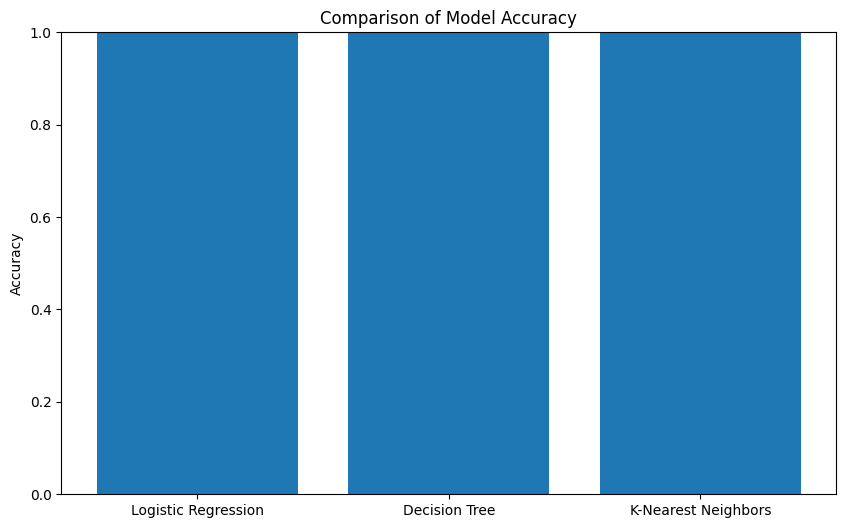

In [11]:
# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions
knn_predictions = knn.predict(X_test)

# Evaluate the model
print("\nK-Nearest Neighbors Model:")
print(f"Accuracy: {accuracy_score(y_test, knn_predictions):.4f}")
print(f"Precision: {precision_score(y_test, knn_predictions, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, knn_predictions, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, knn_predictions, average='weighted'):.4f}")

# Compare the models
models = ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors']
scores = [accuracy_score(y_test, log_reg_predictions),
         accuracy_score(y_test, tree_predictions),
         accuracy_score(y_test, knn_predictions)]

plt.figure(figsize=(10, 6))
plt.bar(models, scores)
plt.title('Comparison of Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

## 6. Building a Simple Regression Model

Let's now build a regression model to predict continuous values. We'll use the Boston housing dataset for this example.

In [12]:
# Load the California housing dataset (Boston housing dataset is deprecated)
california = datasets.fetch_california_housing()

# Explore the dataset
print("Dataset keys:", california.keys())
print("\nFeature names:", california.feature_names)
print("\nData shape:", california.data.shape)
print("\nTarget shape:", california.target.shape)

# Prepare the data
X = california.data
y = california.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Dataset keys: dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Data shape: (20640, 8)

Target shape: (20640,)
Training set shape: (14448, 8)
Testing set shape: (6192, 8)


In [13]:
# Train a linear regression model
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Make predictions
linear_reg_predictions = linear_reg.predict(X_test)

# Evaluate the model
linear_reg_mse = mean_squared_error(y_test, linear_reg_predictions)
linear_reg_rmse = np.sqrt(linear_reg_mse)
linear_reg_r2 = r2_score(y_test, linear_reg_predictions)

print("\nLinear Regression Model:")
print(f"Mean Squared Error: {linear_reg_mse:.4f}")
print(f"Root Mean Squared Error: {linear_reg_rmse:.4f}")
print(f"R² Score: {linear_reg_r2:.4f}")


Linear Regression Model:
Mean Squared Error: 0.5306
Root Mean Squared Error: 0.7284
R² Score: 0.5958


In [14]:
# Train a ridge regression model (linear regression with L2 regularization)
ridge_reg = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge_reg.fit(X_train, y_train)

# Make predictions
ridge_reg_predictions = ridge_reg.predict(X_test)

# Evaluate the model
ridge_reg_mse = mean_squared_error(y_test, ridge_reg_predictions)
ridge_reg_rmse = np.sqrt(ridge_reg_mse)
ridge_reg_r2 = r2_score(y_test, ridge_reg_predictions)

print("\nRidge Regression Model:")
print(f"Mean Squared Error: {ridge_reg_mse:.4f}")
print(f"Root Mean Squared Error: {ridge_reg_rmse:.4f}")
print(f"R² Score: {ridge_reg_r2:.4f}")


Ridge Regression Model:
Mean Squared Error: 0.5305
Root Mean Squared Error: 0.7284
R² Score: 0.5958



Decision Tree Regressor:
Mean Squared Error: 0.5280
Root Mean Squared Error: 0.7266
R² Score: 0.5977


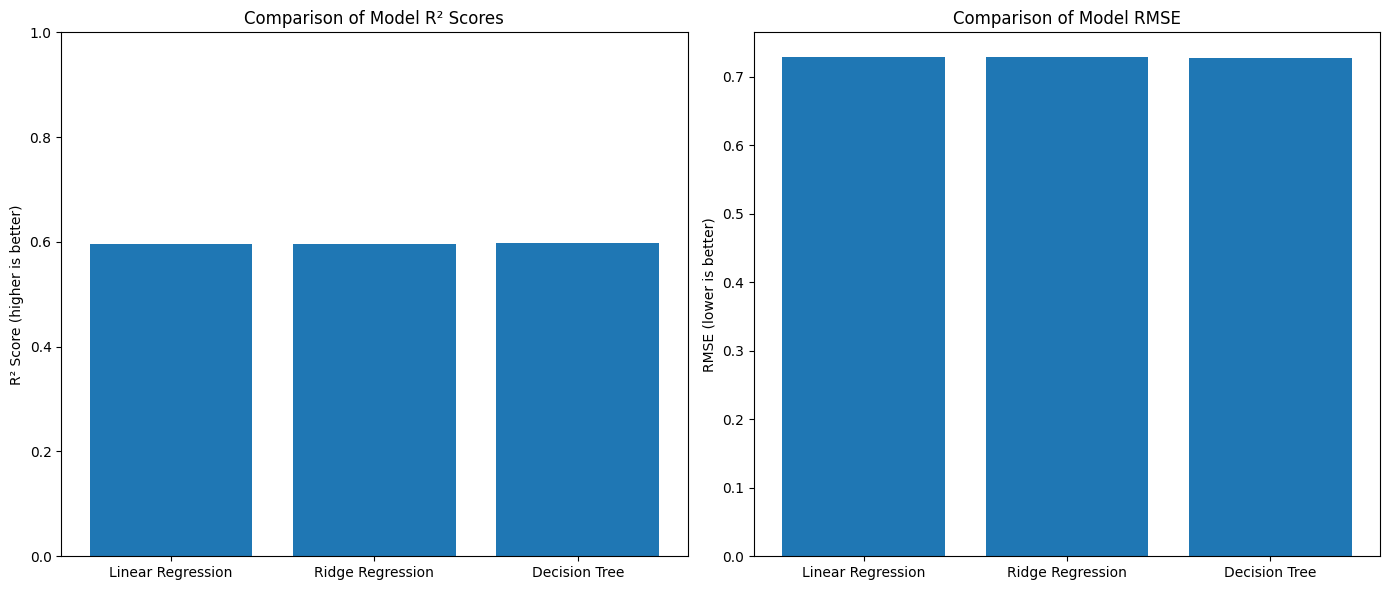

In [15]:
# Train a decision tree regressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Make predictions
tree_reg_predictions = tree_reg.predict(X_test)

# Evaluate the model
tree_reg_mse = mean_squared_error(y_test, tree_reg_predictions)
tree_reg_rmse = np.sqrt(tree_reg_mse)
tree_reg_r2 = r2_score(y_test, tree_reg_predictions)

print("\nDecision Tree Regressor:")
print(f"Mean Squared Error: {tree_reg_mse:.4f}")
print(f"Root Mean Squared Error: {tree_reg_rmse:.4f}")
print(f"R² Score: {tree_reg_r2:.4f}")

# Compare the regression models
models = ['Linear Regression', 'Ridge Regression', 'Decision Tree']
r2_scores = [linear_reg_r2, ridge_reg_r2, tree_reg_r2]
rmse_scores = [linear_reg_rmse, ridge_reg_rmse, tree_reg_rmse]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot R² scores
ax[0].bar(models, r2_scores)
ax[0].set_title('Comparison of Model R² Scores')
ax[0].set_ylabel('R² Score (higher is better)')
ax[0].set_ylim(0, 1)

# Plot RMSE scores
ax[1].bar(models, rmse_scores)
ax[1].set_title('Comparison of Model RMSE')
ax[1].set_ylabel('RMSE (lower is better)')

plt.tight_layout()
plt.show()

## 7. Model Evaluation Techniques

Scikit-learn provides various tools for evaluating machine learning models, including cross-validation and different metrics for classification and regression tasks.

In [16]:
# Cross-validation for classification (using the Iris dataset)
print("Cross-validation with different classifiers (Iris dataset):")

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, clf in classifiers.items():
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(clf, iris.data, iris.target, cv=5, scoring='accuracy')
    
    # Print results
    print(f"\n{name}:")
    print(f"  Cross-validation scores: {cv_scores.round(4)}")
    print(f"  Mean accuracy: {cv_scores.mean():.4f}")
    print(f"  Standard deviation: {cv_scores.std():.4f}")

Cross-validation with different classifiers (Iris dataset):

Logistic Regression:
  Cross-validation scores: [0.9667 1.     0.9333 0.9667 1.    ]
  Mean accuracy: 0.9733
  Standard deviation: 0.0249

K-Nearest Neighbors:
  Cross-validation scores: [0.9667 0.9667 0.9333 0.9667 1.    ]
  Mean accuracy: 0.9667
  Standard deviation: 0.0211

Decision Tree:
  Cross-validation scores: [0.9667 0.9667 0.9    0.9333 1.    ]
  Mean accuracy: 0.9533
  Standard deviation: 0.0340


In [17]:
# Cross-validation for regression (using the California housing dataset)
print("\nCross-validation with different regressors (California housing dataset):")

regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42)
}

for name, reg in regressors.items():
    # Perform 5-fold cross-validation for R²
    r2_scores = cross_val_score(reg, california.data, california.target, cv=5, scoring='r2')
    
    # Perform 5-fold cross-validation for neg_mean_squared_error
    # Note: Scikit-learn's scorers are all defined so that higher values are better
    # So for error metrics, they use the negative of the error
    mse_scores = -cross_val_score(reg, california.data, california.target, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(mse_scores)
    
    # Print results
    print(f"\n{name}:")
    print(f"  R² scores: {r2_scores.round(4)}")
    print(f"  Mean R²: {r2_scores.mean():.4f}")
    print(f"  RMSE scores: {rmse_scores.round(4)}")
    print(f"  Mean RMSE: {rmse_scores.mean():.4f}")


Cross-validation with different regressors (California housing dataset):

Linear Regression:
  R² scores: [0.5487 0.4682 0.5508 0.537  0.6605]
  Mean R²: 0.5530
  RMSE scores: [0.6963 0.789  0.8039 0.737  0.7033]
  Mean RMSE: 0.7459

Ridge Regression:
  R² scores: [0.5488 0.4682 0.5508 0.5369 0.6605]
  Mean R²: 0.5530
  RMSE scores: [0.6962 0.789  0.8039 0.7371 0.7033]
  Mean RMSE: 0.7459

Decision Tree Regressor:
  R² scores: [0.2709 0.4137 0.4391 0.2357 0.4188]
  Mean R²: 0.3556
  RMSE scores: [0.885  0.8284 0.8982 0.9469 0.9203]
  Mean RMSE: 0.8958


## 8. Pipeline and Feature Union

Scikit-learn's Pipeline and FeatureUnion are powerful tools for creating efficient and maintainable machine learning workflows. They allow you to chain preprocessing steps and models together, making it easier to apply the same sequence of operations to both training and test data.

In [18]:
# Create a pipeline for classification on the Iris dataset

# 1. Define the pipeline
classification_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale the data
    ('classifier', LogisticRegression(max_iter=1000))  # Step 2: Apply the classifier
])

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42)

# 3. Train the pipeline
classification_pipeline.fit(X_train, y_train)

# 4. Make predictions
pipeline_predictions = classification_pipeline.predict(X_test)

# 5. Evaluate the pipeline
pipeline_accuracy = accuracy_score(y_test, pipeline_predictions)
print("Classification Pipeline Results:")
print(f"Accuracy: {pipeline_accuracy:.4f}")

Classification Pipeline Results:
Accuracy: 1.0000


In [20]:
# Create a more complex pipeline with preprocessing steps

# Let's create a dataset with missing values and different scales
X = np.array([
    [np.nan, 2, 3, 4],
    [3, 4, np.nan, 6],
    [1, 2, 9, 8],
    [np.nan, 2, 3, 4],
    [5, np.nan, 1, 4]
])
y = np.array([0, 1, 1, 0, 1])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Define a pipeline with multiple preprocessing steps
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Step 1: Impute missing values
    ('scaler', StandardScaler())  # Step 2: Scale the data
])

# Define the full pipeline with preprocessing and model
full_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),  # Apply preprocessing
    ('classifier', KNeighborsClassifier(n_neighbors=3))  # Apply classifier
])

# Train the pipeline
full_pipeline.fit(X_train, y_train)

# Make predictions
pipeline_predictions = full_pipeline.predict(X_test)

# Evaluate
print("\nFull Pipeline with Preprocessing Steps:")
print(f"Predictions: {pipeline_predictions}")
print(f"Actual: {y_test}")
print(f"Accuracy: {accuracy_score(y_test, pipeline_predictions):.4f}")


Full Pipeline with Preprocessing Steps:
Predictions: [0]
Actual: [1]
Accuracy: 0.0000


In [21]:
# Using GridSearchCV with a pipeline to find best parameters

from sklearn.model_selection import GridSearchCV

# Create a pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# Parameter grid to search
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
}

# Set up GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

# Train on the Iris dataset
grid_search.fit(iris.data, iris.target)

# Print results
print("\nGrid Search Results:")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use the best model to make predictions
best_model = grid_search.best_estimator_
predictions = best_model.predict(iris.data[:5])
print(f"Sample predictions: {predictions}")
print(f"Actual values: {iris.target[:5]}")


Grid Search Results:
Best parameters: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
Best cross-validation score: 0.9667
Sample predictions: [0 0 0 0 0]
Actual values: [0 0 0 0 0]


## Summary

In this notebook, we've covered the fundamental concepts of scikit-learn:

1. **Core Components**: Estimators, Predictors, Transformers, and their consistent API
2. **Built-in Datasets**: Loading and exploring structured datasets like Iris and California housing
3. **Data Preprocessing**: Techniques for scaling, encoding, and handling missing values
4. **Classification Models**: Building and evaluating classifiers like Logistic Regression, Decision Trees, and KNN
5. **Regression Models**: Implementing and evaluating regression models like Linear Regression and Decision Tree Regressors
6. **Model Evaluation**: Using cross-validation and appropriate metrics for model assessment
7. **Pipelines**: Building efficient ML workflows by chaining preprocessing steps and models

Scikit-learn provides a consistent, easy-to-use interface for machine learning tasks while offering a wide range of algorithms and tools. This makes it an excellent library for both beginners and experienced practitioners.